# **Vanilla Transformer Baseline All Sensors**

## **Libraries Import**

In [1]:
from preprocessing import CMAPSS, preprocessing, create_windows
from Models import FirstBaseline
from Training import train
from Testing import test
from dataloading import load_data
from torch.utils.data import DataLoader
import torch
from torch import nn
from plots import plot_predictions

pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128
pip install scikit-learn h5py

### **GPU check**

In [2]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Current GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU count: {torch.cuda.device_count()}")
print(f"MPS available: {torch.backends.mps.is_available()}")

PyTorch version: 2.11.0+cu128
CUDA available: True
Current GPU: NVIDIA GeForce RTX 4060 Ti
GPU count: 1
MPS available: False


### **Data load**

In [4]:
# data loading
filename = '../data_set/N-CMAPSS_DS02-006.h5'
W, X_s, X_v, T, Y, A, W_var, X_s_var, X_v_var, T_var, A_var, train_df, test_df = load_data(filename)
print(f"Unique units in train_df: {train_df['unit'].unique()}")
print(f"Shape of train_df: {train_df.shape}")
train_df.head()



Operation time (min):  0.04739583333333333

W shape: (6517190, 4)
X_s shape: (6517190, 14)
X_v shape: (6517190, 14)
T shape: (6517190, 10)
A shape: (6517190, 4)
Unique units in train_df: [ 2  5 10 16 18 20]
Shape of train_df: (5263447, 37)


,unit,cycle,Fc,hs,alt,Mach,TRA,T2,T24,T30,...,W25,W31,W32,W48,W50,SmFan,SmLPC,SmHPC,phi,RUL
0,2,1.0,3,1,10005.0,0.448497,76.903748,502.420918,600.148034,1438.498187,...,228.487065,26.498785,15.899271,215.844851,228.411666,16.648833,9.898130,25.376144,41.893990,74.0
1,2,1.0,3,1,10013.0,0.447741,76.903748,502.326114,600.055894,1438.350208,...,228.383505,26.486552,15.891931,215.745634,228.307014,16.639222,9.904927,25.380549,41.884434,74.0
2,2,1.0,3,1,10017.0,0.448938,77.079529,502.416067,600.210756,1439.109101,...,228.661083,26.519340,15.911604,216.019054,228.592279,16.649823,9.923503,25.318848,41.953848,74.0
3,2,1.0,3,1,10024.0,0.449883,77.079529,502.469893,600.369717,1439.240230,...,228.768625,26.532044,15.919226,216.121238,228.702994,16.653812,9.905518,25.361981,41.914342,74.0
4,2,1.0,3,1,10031.0,0.449379,77.079529,502.401271,600.298227,1439.064004,...,228.653631,26.518460,15.911076,216.008509,228.584788,16.649031,9.897465,25.363994,41.911503,74.0


In [4]:
print(f"Unique units in test_df: {test_df['unit'].unique()}")
print(f"Shape of test_df: {test_df.shape}")
test_df.head()

Unique units in test_df: [11 14 15]
Shape of test_df: (1253743, 37)


,unit,cycle,Fc,hs,alt,Mach,TRA,T2,T24,T30,...,W25,W31,W32,W48,W50,SmFan,SmLPC,SmHPC,phi,RUL
0,11,1.0,3,1,10014.0,0.457506,77.25531,503.176696,601.369822,1441.086963,...,229.763207,26.649529,15.989717,217.085529,229.722454,16.745510,9.812495,25.345244,41.971419,58.0
1,11,1.0,3,1,10020.0,0.457947,77.25531,503.192949,601.381211,1441.055436,...,229.736365,26.646358,15.987815,217.058720,229.694212,16.751997,9.806257,25.346932,41.971470,58.0
2,11,1.0,3,1,10029.0,0.458451,77.25531,503.203187,601.392126,1441.063188,...,229.719527,26.644369,15.986621,217.043190,229.677650,16.758975,9.804009,25.348326,41.969940,58.0
3,11,1.0,3,1,10034.0,0.458136,77.25531,503.158580,601.348485,1440.964145,...,229.655911,26.636854,15.982113,216.981145,229.612403,16.755378,9.803649,25.352080,41.964794,58.0
4,11,1.0,3,1,10045.0,0.458010,77.25531,503.105629,601.285695,1440.852510,...,229.561414,26.625692,15.975415,216.890123,229.516137,16.753262,9.806697,25.351024,41.963540,58.0


### **Data preprocessing**

In [ ]:
features = W_var + X_s_var + X_v_var# features selection

X_train_scaled_df, X_test_scaled_df, Y_train, Y_test = preprocessing(True, train_df, test_df, features)
print("Preprocessing completed.")
print("Training set shape:", X_train_scaled_df.shape, "Training labels shape:", Y_train.shape)
print("Testing set shape:", X_test_scaled_df.shape, "Testing labels shape:", Y_test.shape)

✓ Data Normalization

Preprocessing completed.
Training set shape: (5263447, 35) Training labels shape: (5263447,)
Testing set shape: (1253743, 35) Testing labels shape: (1253743,)


### **Window processing**

In [ ]:
train_engine_df = X_train_scaled_df[X_train_scaled_df['unit'] != 18]
val_engine_df   = X_train_scaled_df[X_train_scaled_df['unit'] == 18]

print(f"Shape of train_engine_df: {train_engine_df.shape} and engine units: {train_engine_df['unit'].unique()}")
print(f"Shape of val_engine_df: {val_engine_df.shape} and engine units: {val_engine_df['unit'].unique()}")
print(f"Shape of X_test_scaled_df: {X_test_scaled_df.shape} and engine units: {X_test_scaled_df['unit'].unique()}")

X_windows_train, Y_windows_train = create_windows(train_engine_df, features, window_size=50, stride=15)
X_windows_val, Y_windows_val     = create_windows(val_engine_df, features, window_size=50, stride=15)
X_windows_test, Y_windows_test = create_windows(X_test_scaled_df, features, window_size=50, stride=15)

print("X train normalized windows shape:",X_windows_train.shape,"\n Y train windows  shape:" , Y_windows_train.shape)
print("X val windows shape:",X_windows_val.shape,"\n Y val windows  shape:" , Y_windows_val.shape) # engine (18) for validating
print("X test windows shape:",X_windows_test.shape,"\n Y test windows  shape:" , Y_windows_test.shape)


Shape of train_engine_df: (4372728, 35) and engine units: [ 2  5 10 16 20]
Shape of val_engine_df: (890719, 35) and engine units: [18]
Shape of X_test_scaled_df: (1253743, 35) and engine units: [11 14 15]
X train normalized windows shape: (291501, 50, 32) 
 Y train windows  shape: (291501,)
X val windows shape: (59378, 50, 32) 
 Y val windows  shape: (59378,)
X test windows shape: (83574, 50, 32) 
 Y test windows  shape: (83574,)


### **Dataset & dataloader setup**

In [7]:
dataset_train = CMAPSS(X_windows_train, Y_windows_train)
dataset_val   = CMAPSS(X_windows_val, Y_windows_val)
dataset_test  = CMAPSS(X_windows_test, Y_windows_test)

train_loader = DataLoader(dataset_train, batch_size=64, shuffle=True)
val_loader   = DataLoader(dataset_val, batch_size=64, shuffle=False)
test_loader  = DataLoader(dataset_test, batch_size=64, shuffle=False)

oneloader = next(iter(train_loader))
print(type(oneloader))
print(len(oneloader))
for item in oneloader:
    print(type(item), getattr(item, "shape", None))

<class 'list'>
2
<class 'torch.Tensor'> torch.Size([64, 50, 32])
<class 'torch.Tensor'> torch.Size([64, 1])


### **Model setup**

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FirstBaseline(num_features=len(features))
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3, weight_decay=1e-2)
trained_model, train_preds, train_targets, val_preds, val_targets = train(
    criterion, optimizer, train_loader, val_loader, model, num_epochs=1
)
test_loss, test_rmse, test_nasa, test_preds, test_targets = test(
    trained_model, test_loader, criterion
)

# for test
plot_predictions(train_targets, train_preds, split_name="Train")
plot_predictions(val_targets, val_preds, split_name="Validation")
plot_predictions(test_targets, test_preds, split_name="Test")

## **Training & Testing**

#### **Train with physical & virtual sensors**

Configuration: lr: 0.001, dropout: 0.1, dimensionality of the model: 64
cuda
cuda:0
Epoch 1/20 - LR: 0.001000 - Train Loss: 530.2673 - Train RMSE: 23.0275 - Train NASA mean: 9.1574 - Train NASA total: 2669392.12 - Val Loss: 458.8927 - Val RMSE: 21.4218 - Val NASA mean: 8.8656 - Val NASA total: 526420.12
Epoch 2/20 - LR: 0.001000 - Train Loss: 512.8705 - Train RMSE: 22.6466 - Train NASA mean: 8.5852 - Train NASA total: 2502600.63 - Val Loss: 464.9485 - Val RMSE: 21.5627 - Val NASA mean: 9.2525 - Val NASA total: 549396.74
Epoch 3/20 - LR: 0.001000 - Train Loss: 512.9740 - Train RMSE: 22.6489 - Train NASA mean: 8.5861 - Train NASA total: 2502850.67 - Val Loss: 448.6643 - Val RMSE: 21.1817 - Val NASA mean: 8.1797 - Val NASA total: 485697.17
Epoch 4/20 - LR: 0.001000 - Train Loss: 512.9862 - Train RMSE: 22.6492 - Train NASA mean: 8.5870 - Train NASA total: 2503116.99 - Val Loss: 460.2618 - Val RMSE: 21.4537 - Val NASA mean: 8.9539 - Val NASA total: 531666.49
Epoch 5/20 - LR: 0.001000 - Trai

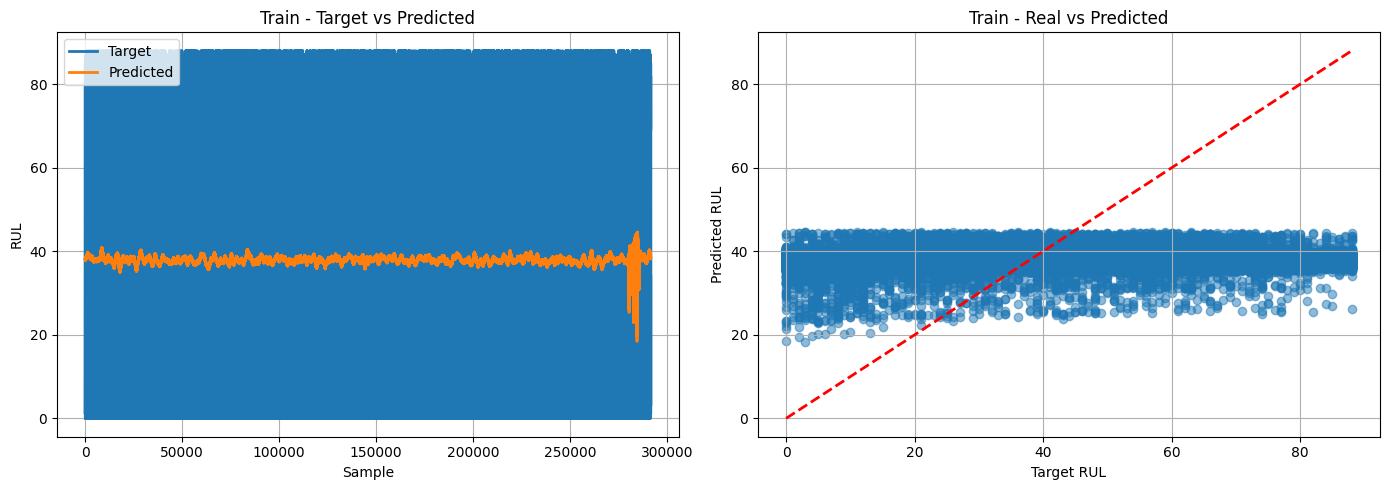

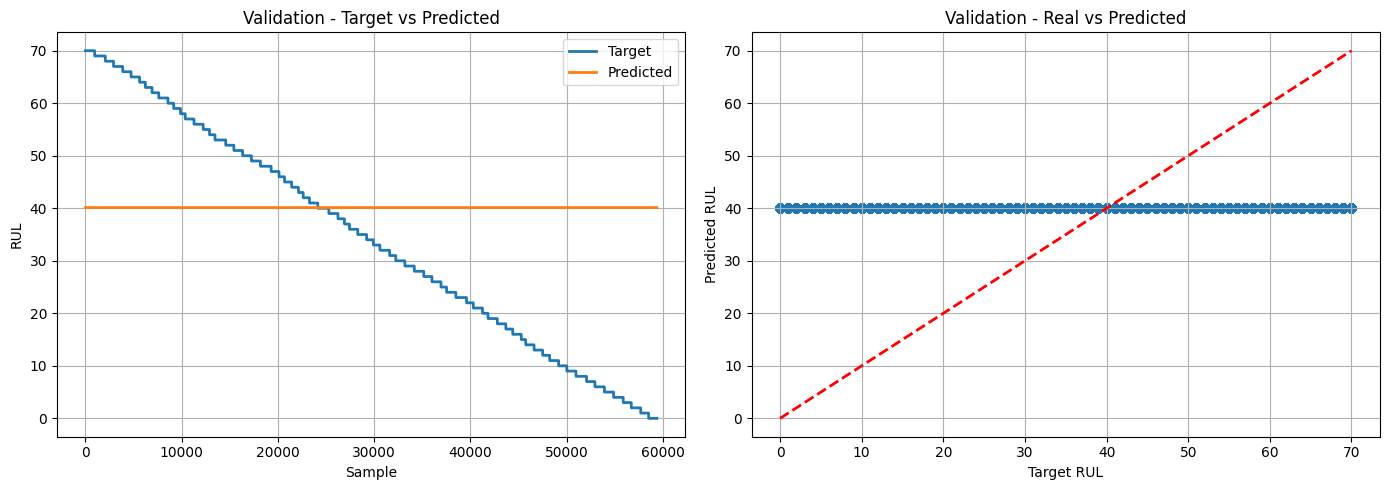

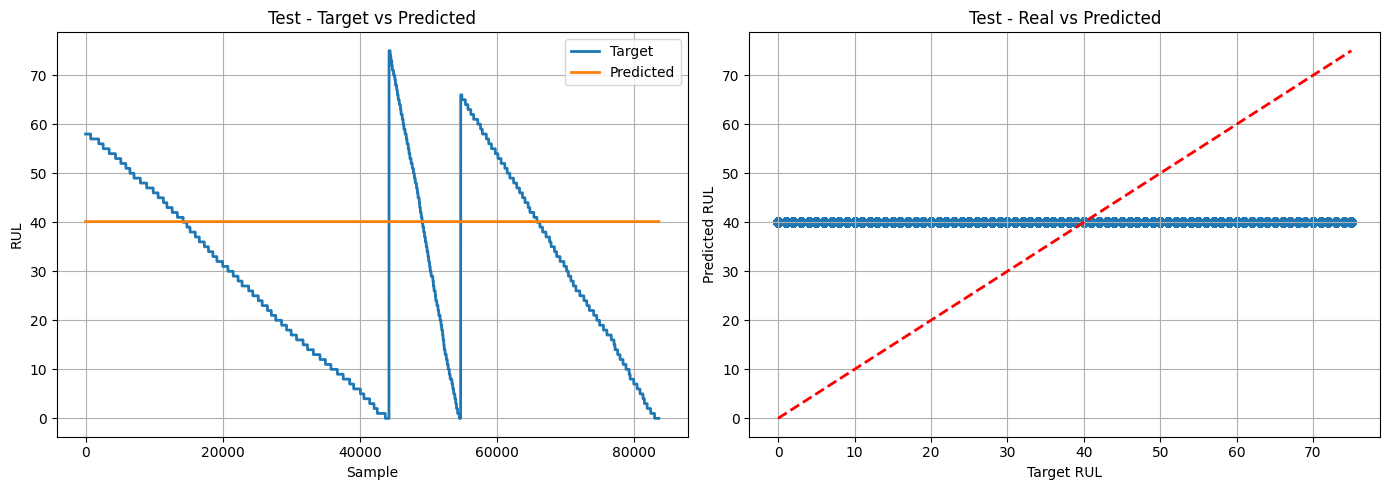

Configuration: lr: 0.0005, dropout: 0.2, dimensionality of the model: 64
cuda
cuda:0
Epoch 1/20 - LR: 0.000500 - Train Loss: 552.8130 - Train RMSE: 23.5120 - Train NASA mean: 9.8984 - Train NASA total: 2885402.22 - Val Loss: 475.7360 - Val RMSE: 21.8114 - Val NASA mean: 9.9244 - Val NASA total: 589293.84
Epoch 2/20 - LR: 0.000500 - Train Loss: 512.6852 - Train RMSE: 22.6426 - Train NASA mean: 8.5756 - Train NASA total: 2499801.60 - Val Loss: 461.1359 - Val RMSE: 21.4741 - Val NASA mean: 9.0100 - Val NASA total: 534996.75
Epoch 3/20 - LR: 0.000500 - Train Loss: 512.7043 - Train RMSE: 22.6430 - Train NASA mean: 8.5775 - Train NASA total: 2500351.32 - Val Loss: 470.6359 - Val RMSE: 21.6941 - Val NASA mean: 9.6092 - Val NASA total: 570577.66
Epoch 4/20 - LR: 0.000500 - Train Loss: 387.9612 - Train RMSE: 19.6967 - Train NASA mean: 6.3594 - Train NASA total: 1853771.66 - Val Loss: 85.4200 - Val RMSE: 9.2423 - Val NASA mean: 1.5767 - Val NASA total: 93623.20
Epoch 5/20 - LR: 0.000500 - Train 

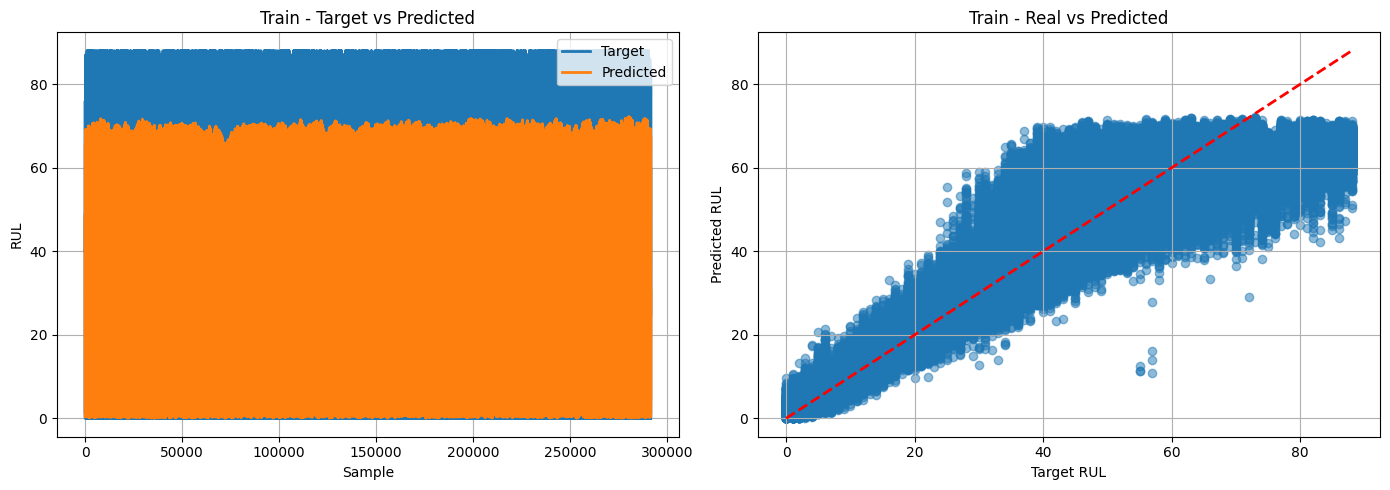

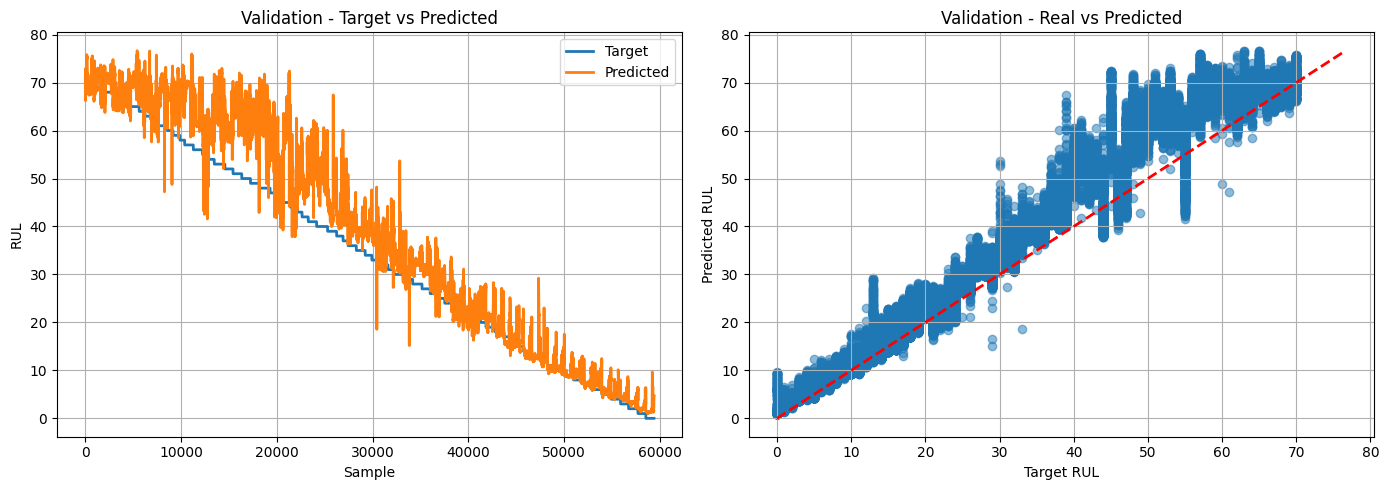

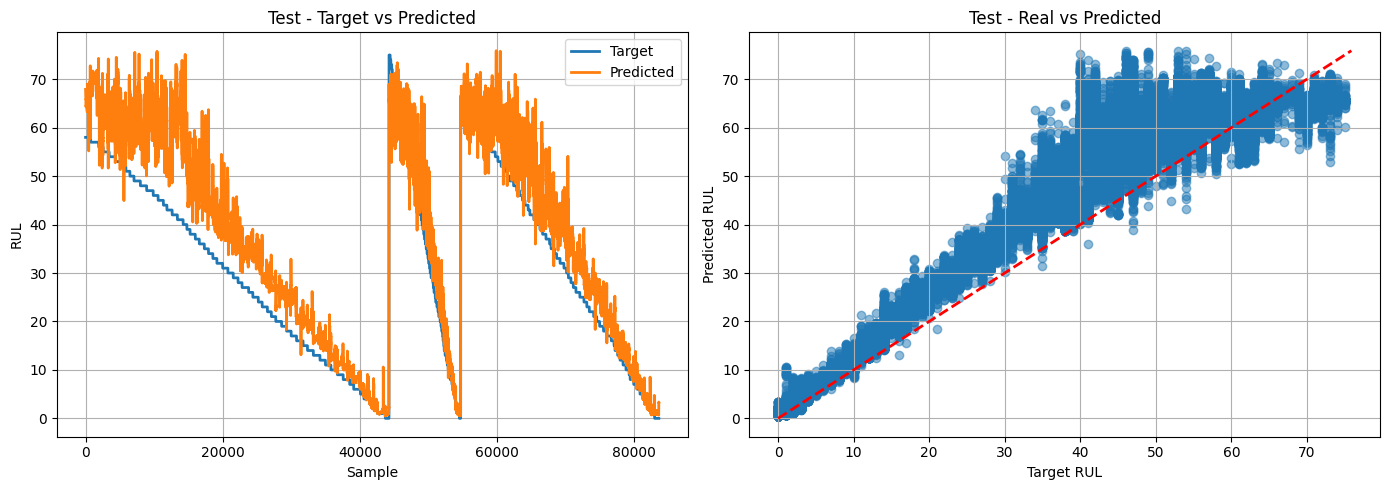

Configuration: lr: 0.0001, dropout: 0.3, dimensionality of the model: 32
cuda
cuda:0
Epoch 1/20 - LR: 0.000100 - Train Loss: 573.3544 - Train RMSE: 23.9448 - Train NASA mean: 12.1442 - Train NASA total: 3540059.10 - Val Loss: 364.3495 - Val RMSE: 19.0879 - Val NASA mean: 7.6088 - Val NASA total: 451793.74
Epoch 2/20 - LR: 0.000100 - Train Loss: 164.2333 - Train RMSE: 12.8154 - Train NASA mean: 2.3614 - Train NASA total: 688339.08 - Val Loss: 137.8368 - Val RMSE: 11.7404 - Val NASA mean: 2.5182 - Val NASA total: 149527.72
Epoch 3/20 - LR: 0.000100 - Train Loss: 142.2862 - Train RMSE: 11.9284 - Train NASA mean: 2.0352 - Train NASA total: 593250.14 - Val Loss: 141.7605 - Val RMSE: 11.9063 - Val NASA mean: 2.6755 - Val NASA total: 158866.57
Epoch 4/20 - LR: 0.000100 - Train Loss: 124.0392 - Train RMSE: 11.1373 - Train NASA mean: 1.7542 - Train NASA total: 511345.71 - Val Loss: 199.0006 - Val RMSE: 14.1068 - Val NASA mean: 3.5649 - Val NASA total: 211674.53
Epoch 5/20 - LR: 0.000100 - Train

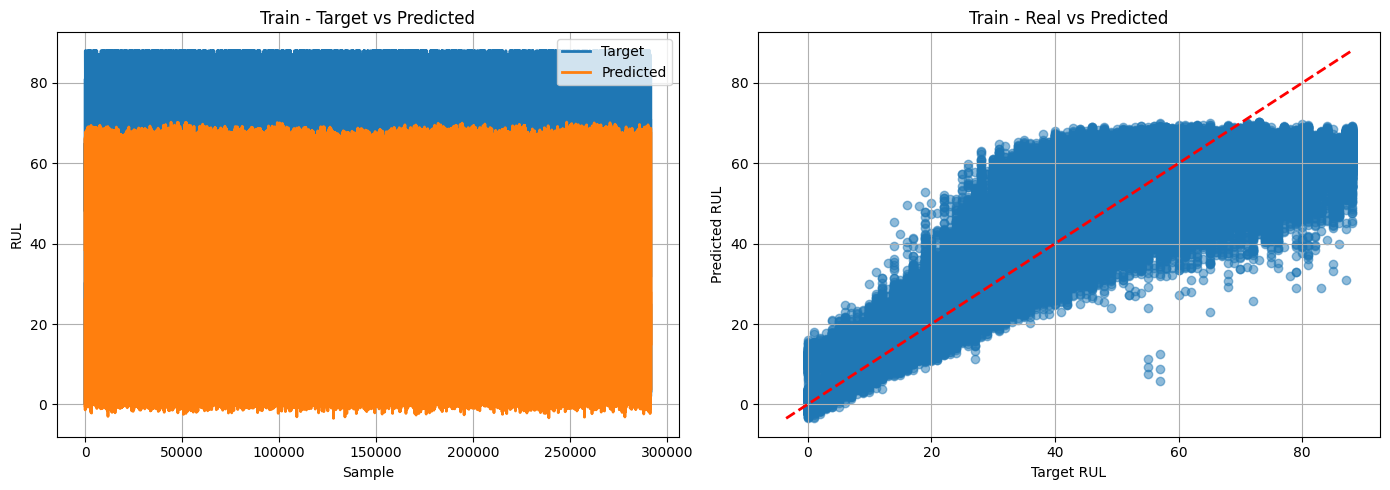

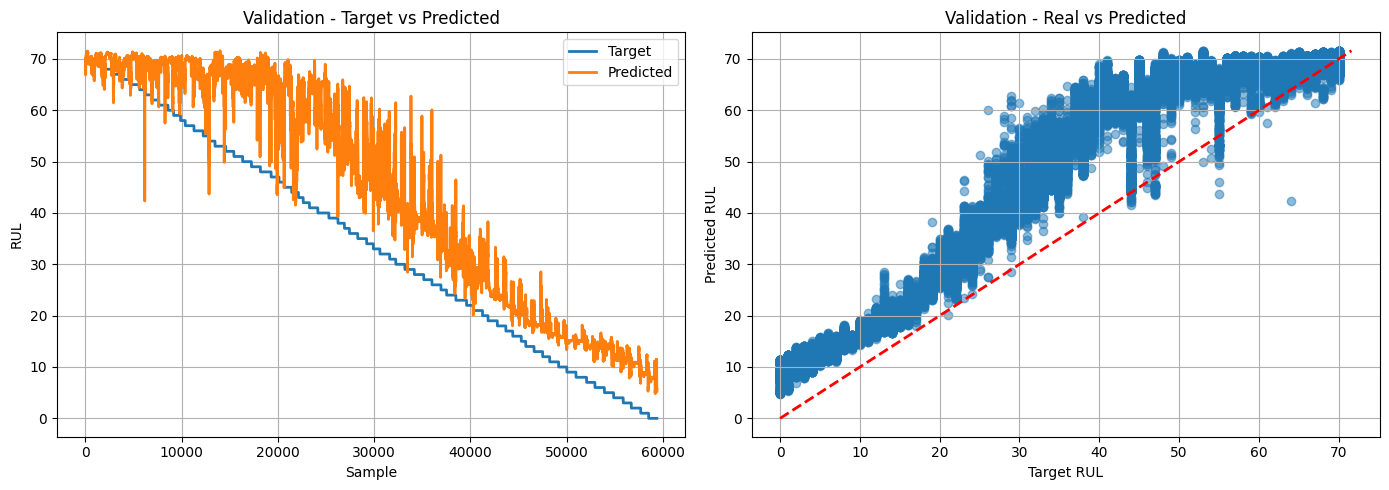

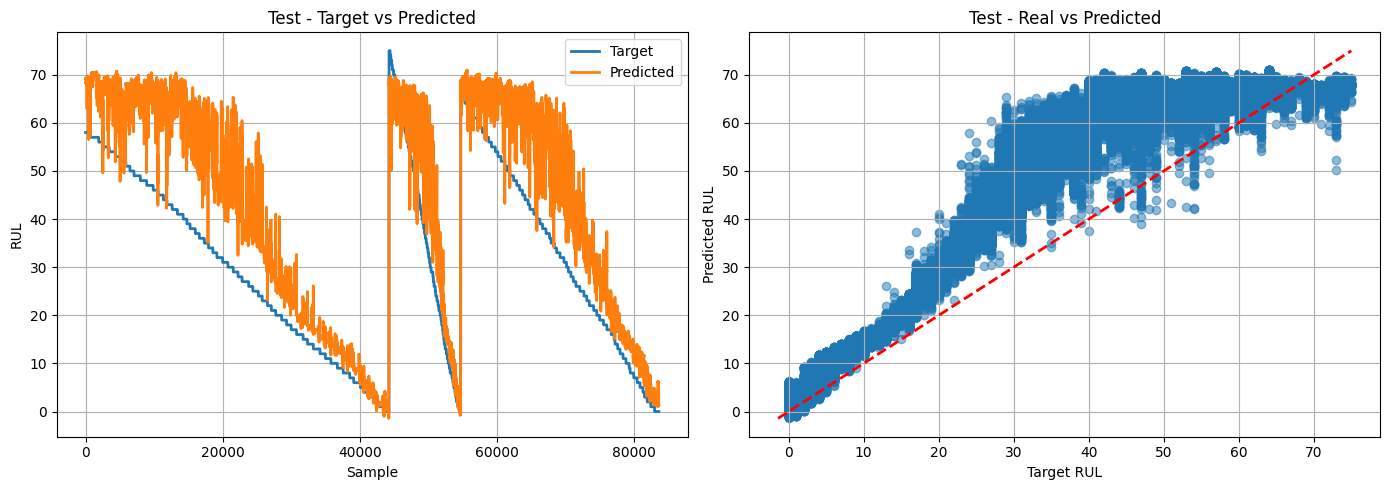

In [ ]:
search_space = [
    {"lr": 1e-3, "dropout": 0.1, "d_model": 64},
    {"lr": 5e-4, "dropout": 0.2, "d_model": 64},
    {"lr": 1e-4, "dropout": 0.3, "d_model": 32},
]

best_val_rmse = float("inf")
best_config = None
criterion = nn.MSELoss()
for config in search_space:
    model = FirstBaseline(
        num_features=len(features),
        d_model=config["d_model"],
        dropout=config["dropout"]
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config["lr"],
        weight_decay=1e-4
    )

    print(f'Configuration: lr: {config["lr"]}, dropout: {config["dropout"]}, dimensionality of the model: {config["d_model"]}')

    trained_model, train_preds, train_targets, val_preds, val_targets = train(
    criterion, optimizer, train_loader, val_loader, model, num_epochs=20
    )

    test_loss, test_rmse, test_nasa, test_preds, test_targets = test(trained_model, test_loader, criterion)
    # evaluate val RMSE here and compare
    plot_predictions(train_targets, train_preds, split_name="Train")
    plot_predictions(val_targets, val_preds, split_name="Validation")
    plot_predictions(test_targets, test_preds, split_name="Test")

## **Optuna parameters tunning**

#### **Train with physical & virtual sensors**

In [ ]:
!pip install optuna

In [ ]:
import optuna



def objective(trial):
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    
    d_model = trial.suggest_categorical("d_model", [32, 64, 128])
    nhead = trial.suggest_categorical("nhead", [2, 4, 8])

    if d_model % nhead != 0:
        raise optuna.TrialPruned()

    num_layers = trial.suggest_int("num_layers", 1, 3)
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    dim_feedforward = trial.suggest_categorical("dim_feedforward", [64, 128, 256])
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])
    num_epochs = trial.suggest_int("num_epochs", 10, 40)
    window_size = trial.suggest_categorical("window_size", [50, 100, 500])
    stride = trial.suggest_categorical("stride", [15, 20, 30, 40, 150, 200])

    valid_strides = {
        50: [15, 20],
        100: [30, 40],
        500: [150, 200]
    }

    if stride not in valid_strides[window_size]:
        raise optuna.TrialPruned()

    train_engine_df = X_train_scaled_df[X_train_scaled_df['unit'] != 18]
    val_engine_df   = X_train_scaled_df[X_train_scaled_df['unit'] == 18]

    print(f"Shape of train_engine_df: {train_engine_df.shape} and engine units: {train_engine_df['unit'].unique()}")
    print(f"Shape of val_engine_df: {val_engine_df.shape} and engine units: {val_engine_df['unit'].unique()}")
    print(f"Shape of X_test_scaled_df: {X_test_scaled_df.shape} and engine units: {X_test_scaled_df['unit'].unique()}")

    X_windows_train, Y_windows_train = create_windows(train_engine_df, features, window_size=window_size, stride=stride)
    X_windows_val, Y_windows_val     = create_windows(val_engine_df, features, window_size=window_size, stride=stride)
    X_windows_test, Y_windows_test = create_windows(X_test_scaled_df, features, window_size=window_size, stride=stride)

    print("X train normalized windows shape:",X_windows_train.shape,"\n Y train windows  shape:" , Y_windows_train.shape) 
    print("X val windows shape:",X_windows_val.shape,"\n Y val windows  shape:" , Y_windows_val.shape) # engine (18) for validating
    print("X test windows shape:",X_windows_test.shape,"\n Y test windows  shape:" , Y_windows_test.shape) 

    dataset_train = CMAPSS(X_windows_train, Y_windows_train)
    dataset_val   = CMAPSS(X_windows_val, Y_windows_val)
    dataset_test  = CMAPSS(X_windows_test, Y_windows_test)

    train_loader = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(dataset_val, batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(dataset_test, batch_size=batch_size, shuffle=False)

    model = FirstBaseline(
        num_features=len(features),
        d_model=d_model,
        nhead=nhead,
        num_layers=num_layers,
        dim_feedforward=dim_feedforward,
        dropout=dropout
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    criterion = torch.nn.MSELoss()

    model, train_preds, train_targets, val_preds, val_targets = train(
        criterion=criterion,
        optimizer=optimizer,
        train_loader=train_loader,
        val_loader=val_loader,
        model=model,
        num_epochs=num_epochs
    )

    test_loss, test_rmse, test_nasa, test_preds, test_targets = test(model, test_loader, criterion) 
    

    return test_nasa


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)

print(study.best_params)
print(study.best_value)

C:\Users\Student\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-07-12 08:53:00,601] A new study created in memory with name: no-name-e4b62e9c-080c-4531-b224-fb64211532d3


Shape of train_engine_df: (4372728, 35) and engine units: [ 2  5 10 16 20]
Shape of val_engine_df: (890719, 35) and engine units: [18]
Shape of X_test_scaled_df: (1253743, 35) and engine units: [11 14 15]
X train normalized windows shape: (218627, 50, 32) 
 Y train windows  shape: (218627,)
X val windows shape: (44534, 50, 32) 
 Y val windows  shape: (44534,)
X test windows shape: (62682, 50, 32) 
 Y test windows  shape: (62682,)
cuda
cuda:0
Epoch 1/40 - LR: 0.000187 - Train Loss: 291.4541 - Train RMSE: 17.0720 - Train NASA mean: 5.1407 - Train NASA total: 1123896.63 - Val Loss: 162.2315 - Val RMSE: 12.7370 - Val NASA mean: 2.7320 - Val NASA total: 121667.82
Epoch 2/40 - LR: 0.000187 - Train Loss: 99.7435 - Train RMSE: 9.9872 - Train NASA mean: 1.3971 - Train NASA total: 305447.61 - Val Loss: 215.3029 - Val RMSE: 14.6732 - Val NASA mean: 3.7846 - Val NASA total: 168545.31
Epoch 3/40 - LR: 0.000187 - Train Loss: 90.7763 - Train RMSE: 9.5277 - Train NASA mean: 1.2776 - Train NASA total: 

[I 2026-07-12 08:59:35,108] Trial 0 finished with value: 1.8901933284406212 and parameters: {'lr': 0.00018731763766700445, 'd_model': 128, 'nhead': 2, 'num_layers': 1, 'dropout': 0.19944433383756138, 'dim_feedforward': 128, 'weight_decay': 4.038326006521973e-05, 'batch_size': 32, 'num_epochs': 40, 'window_size': 50, 'stride': 20}. Best is trial 0 with value: 1.8901933284406212.


Shape of train_engine_df: (4372728, 35) and engine units: [ 2  5 10 16 20]
Shape of val_engine_df: (890719, 35) and engine units: [18]
Shape of X_test_scaled_df: (1253743, 35) and engine units: [11 14 15]
X train normalized windows shape: (218627, 50, 32) 
 Y train windows  shape: (218627,)
X val windows shape: (44534, 50, 32) 
 Y val windows  shape: (44534,)
X test windows shape: (62682, 50, 32) 
 Y test windows  shape: (62682,)
cuda
cuda:0
Epoch 1/27 - LR: 0.000038 - Train Loss: 1158.2376 - Train RMSE: 34.0329 - Train NASA mean: 28.5793 - Train NASA total: 6248216.85 - Val Loss: 446.7447 - Val RMSE: 21.1363 - Val NASA mean: 5.9517 - Val NASA total: 265055.08
Epoch 2/27 - LR: 0.000038 - Train Loss: 520.2219 - Train RMSE: 22.8084 - Train NASA mean: 8.2922 - Train NASA total: 1812900.22 - Val Loss: 452.4022 - Val RMSE: 21.2697 - Val NASA mean: 8.4381 - Val NASA total: 375783.07
Epoch 3/27 - LR: 0.000038 - Train Loss: 441.6709 - Train RMSE: 21.0160 - Train NASA mean: 7.0563 - Train NASA 

[I 2026-07-12 09:02:18,196] Trial 1 finished with value: 2.478196145439075 and parameters: {'lr': 3.8498890658409976e-05, 'd_model': 128, 'nhead': 8, 'num_layers': 2, 'dropout': 0.2063764912991181, 'dim_feedforward': 64, 'weight_decay': 0.0009267731986837738, 'batch_size': 128, 'num_epochs': 27, 'window_size': 50, 'stride': 20}. Best is trial 0 with value: 1.8901933284406212.
[I 2026-07-12 09:02:18,198] Trial 2 pruned. 
[I 2026-07-12 09:02:18,199] Trial 3 pruned. 


...

Shape of train_engine_df: (4372728, 35) and engine units: [ 2  5 10 16 20]
Shape of val_engine_df: (890719, 35) and engine units: [18]
Shape of X_test_scaled_df: (1253743, 35) and engine units: [11 14 15]
X train normalized windows shape: (218627, 50, 32) 
 Y train windows  shape: (218627,)
X val windows shape: (44534, 50, 32) 
 Y val windows  shape: (44534,)
X test windows shape: (62682, 50, 32) 
 Y test windows  shape: (62682,)
cuda
cuda:0
Epoch 1/19 - LR: 0.000061 - Train Loss: 713.9711 - Train RMSE: 26.7202 - Train NASA mean: 15.1404 - Train NASA total: 3310092.73 - Val Loss: 276.1615 - Val RMSE: 16.6181 - Val NASA mean: 4.9456 - Val NASA total: 220246.54
Epoch 2/19 - LR: 0.000061 - Train Loss: 174.0696 - Train RMSE: 13.1935 - Train NASA mean: 2.5021 - Train NASA total: 547021.77 - Val Loss: 71.9948 - Val RMSE: 8.4850 - Val NASA mean: 1.2563 - Val NASA total: 55949.82
Epoch 3/19 - LR: 0.000061 - Train Loss: 144.1750 - Train RMSE: 12.0073 - Train NASA mean: 2.0506 - Train NASA total

[I 2026-07-12 10:51:07,796] Trial 24 finished with value: 0.6363620742651975 and parameters: {'lr': 6.051503998353029e-05, 'd_model': 32, 'nhead': 2, 'num_layers': 3, 'dropout': 0.13070314842076977, 'dim_feedforward': 64, 'weight_decay': 0.00014230779393453069, 'batch_size': 32, 'num_epochs': 19, 'window_size': 50, 'stride': 20}. Best is trial 10 with value: 0.4635504391463371.
[I 2026-07-12 10:51:07,805] Trial 25 pruned. 
[I 2026-07-12 10:51:07,814] Trial 26 pruned. 
[I 2026-07-12 10:51:07,821] Trial 27 pruned. 


Shape of train_engine_df: (4372728, 35) and engine units: [ 2  5 10 16 20]
Shape of val_engine_df: (890719, 35) and engine units: [18]
Shape of X_test_scaled_df: (1253743, 35) and engine units: [11 14 15]
X train normalized windows shape: (21854, 500, 32) 
 Y train windows  shape: (21854,)
X val windows shape: (4452, 500, 32) 
 Y val windows  shape: (4452,)
X test windows shape: (6262, 500, 32) 
 Y test windows  shape: (6262,)
cuda
cuda:0
Epoch 1/15 - LR: 0.000024 - Train Loss: 1885.9426 - Train RMSE: 43.4274 - Train NASA mean: 64.1188 - Train NASA total: 1401252.35 - Val Loss: 1512.9630 - Val RMSE: 38.8968 - Val NASA mean: 35.6108 - Val NASA total: 158539.06
Epoch 2/15 - LR: 0.000024 - Train Loss: 1812.3759 - Train RMSE: 42.5720 - Train NASA mean: 59.2393 - Train NASA total: 1294615.88 - Val Loss: 1466.0204 - Val RMSE: 38.2886 - Val NASA mean: 33.6387 - Val NASA total: 149759.47
Epoch 3/15 - LR: 0.000024 - Train Loss: 1766.0610 - Train RMSE: 42.0245 - Train NASA mean: 56.3175 - Train 

[I 2026-07-12 10:56:40,122] Trial 28 finished with value: 7.906298577461864 and parameters: {'lr': 2.397468161131032e-05, 'd_model': 64, 'nhead': 4, 'num_layers': 3, 'dropout': 0.13139760995391567, 'dim_feedforward': 256, 'weight_decay': 1.8713183150414091e-06, 'batch_size': 128, 'num_epochs': 15, 'window_size': 500, 'stride': 200}. Best is trial 10 with value: 0.4635504391463371.
[I 2026-07-12 10:56:40,163] Trial 29 pruned. 


{'lr': 0.0005207743283269423, 'd_model': 64, 'nhead': 4, 'num_layers': 3, 'dropout': 0.10254532856431582, 'dim_feedforward': 256, 'weight_decay': 1.031251860159177e-05, 'batch_size': 32, 'num_epochs': 10, 'window_size': 50, 'stride': 20}
0.4635504391463371


### **Best hyperparameters from Optuna**

In [7]:
best_params = study.best_params
print(best_params)
print(study.best_value)

print ("=======================================================================================================")
print ("=======================================================================================================")

top3 = sorted(
    [t for t in study.trials if t.value is not None],
    key=lambda t: t.value
)[:3]

# get best three trials
for i, trial in enumerate(top3, 1):
    print(f"Top {i}: value={trial.value}")
    print(trial.params)


best_window_size = best_params["window_size"]
best_stride = best_params["stride"]
best_d_model = best_params["d_model"]
best_nhead = best_params["nhead"]
best_num_layers = best_params["num_layers"]
best_dropout = best_params["dropout"]
best_dim_feedforward = best_params["dim_feedforward"]
best_weight_decay = best_params["weight_decay"]
best_batch_size = best_params["batch_size"]
best_lr = best_params["lr"]
best_num_epochs = best_params["num_epochs"]

print(
    f"best_window_size: {best_window_size}\n"
    f"best_stride: {best_stride}\n"
    f"best_d_model: {best_d_model}\n"
    f"best_nhead: {best_nhead}\n"
    f"best_num_layers: {best_num_layers}\n"
    f"best_dropout: {best_dropout}\n"
    f"best_dim_feedforward: {best_dim_feedforward}\n"
    f"best_weight_decay: {best_weight_decay}\n"
    f"best_batch_size: {best_batch_size}\n"
    f"best_lr: {best_lr}\n"
    f"best_num_epochs: {best_num_epochs}"
)

{'lr': 0.0005207743283269423, 'd_model': 64, 'nhead': 4, 'num_layers': 3, 'dropout': 0.10254532856431582, 'dim_feedforward': 256, 'weight_decay': 1.031251860159177e-05, 'batch_size': 32, 'num_epochs': 10, 'window_size': 50, 'stride': 20}
0.4635504391463371
Top 1: value=0.4635504391463371
{'lr': 0.0005207743283269423, 'd_model': 64, 'nhead': 4, 'num_layers': 3, 'dropout': 0.10254532856431582, 'dim_feedforward': 256, 'weight_decay': 1.031251860159177e-05, 'batch_size': 32, 'num_epochs': 10, 'window_size': 50, 'stride': 20}
Top 2: value=0.6363620742651975
{'lr': 6.051503998353029e-05, 'd_model': 32, 'nhead': 2, 'num_layers': 3, 'dropout': 0.13070314842076977, 'dim_feedforward': 64, 'weight_decay': 0.00014230779393453069, 'batch_size': 32, 'num_epochs': 19, 'window_size': 50, 'stride': 20}
Top 3: value=0.7073483502989216
{'lr': 0.000282766448809368, 'd_model': 64, 'nhead': 4, 'num_layers': 3, 'dropout': 0.10612304766811591, 'dim_feedforward': 256, 'weight_decay': 1.8651784231607325e-05, 'b

## **Retrain with the best hyperparameters from Optuna**

Shape of train_engine_df: (4372728, 35) and engine units: [ 2  5 10 16 20]
Shape of val_engine_df: (890719, 35) and engine units: [18]
Shape of X_test_scaled_df: (1253743, 35) and engine units: [11 14 15]
X train normalized windows shape: (291501, 50, 32) 
 Y train windows  shape: (291501,)
X val windows shape: (59378, 50, 32) 
 Y val windows  shape: (59378,)
X test windows shape: (83574, 50, 32) 
 Y test windows  shape: (83574,)
cuda
cuda:0
Epoch 1/10 - LR: 0.000521 - Train Loss: 543.9068 - Train RMSE: 23.3218 - Train NASA mean: 9.5463 - Train NASA total: 2782751.36 - Val Loss: 449.2216 - Val RMSE: 21.1948 - Val NASA mean: 8.2187 - Val NASA total: 488010.60
Epoch 2/10 - LR: 0.000521 - Train Loss: 512.7130 - Train RMSE: 22.6432 - Train NASA mean: 8.5777 - Train NASA total: 2500395.24 - Val Loss: 460.8558 - Val RMSE: 21.4676 - Val NASA mean: 8.9921 - Val NASA total: 533930.37
Epoch 3/10 - LR: 0.000521 - Train Loss: 512.2256 - Train RMSE: 22.6324 - Train NASA mean: 8.5691 - Train NASA to

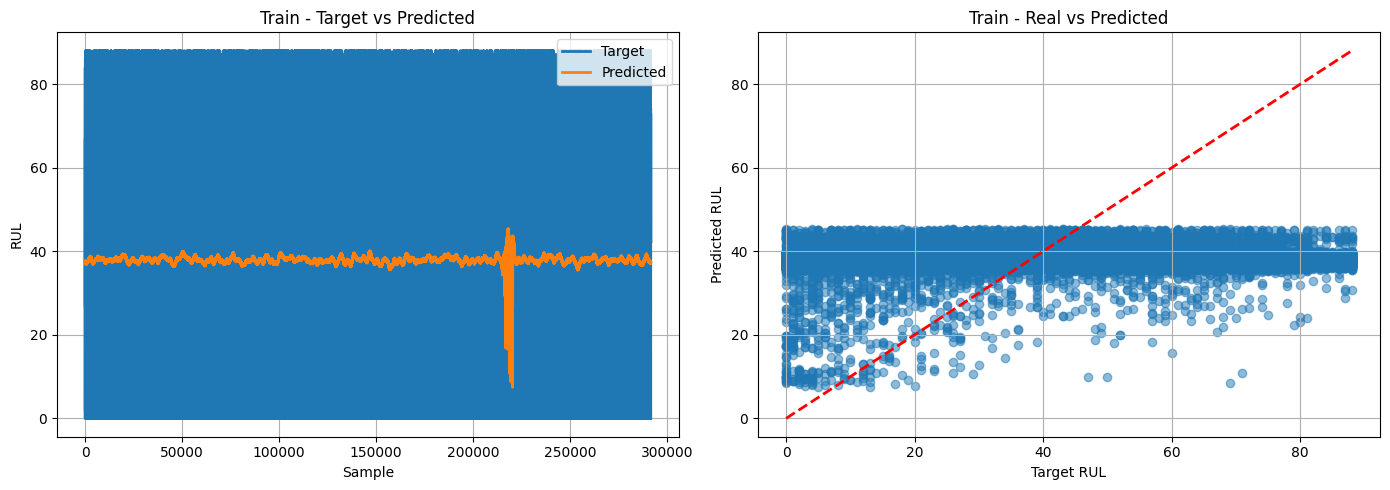

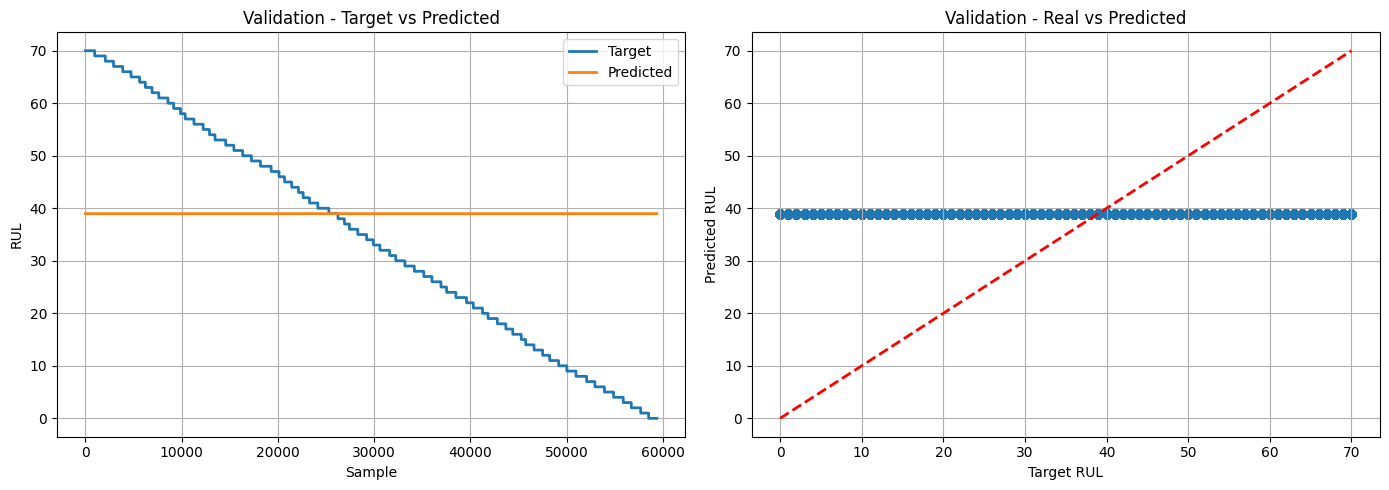

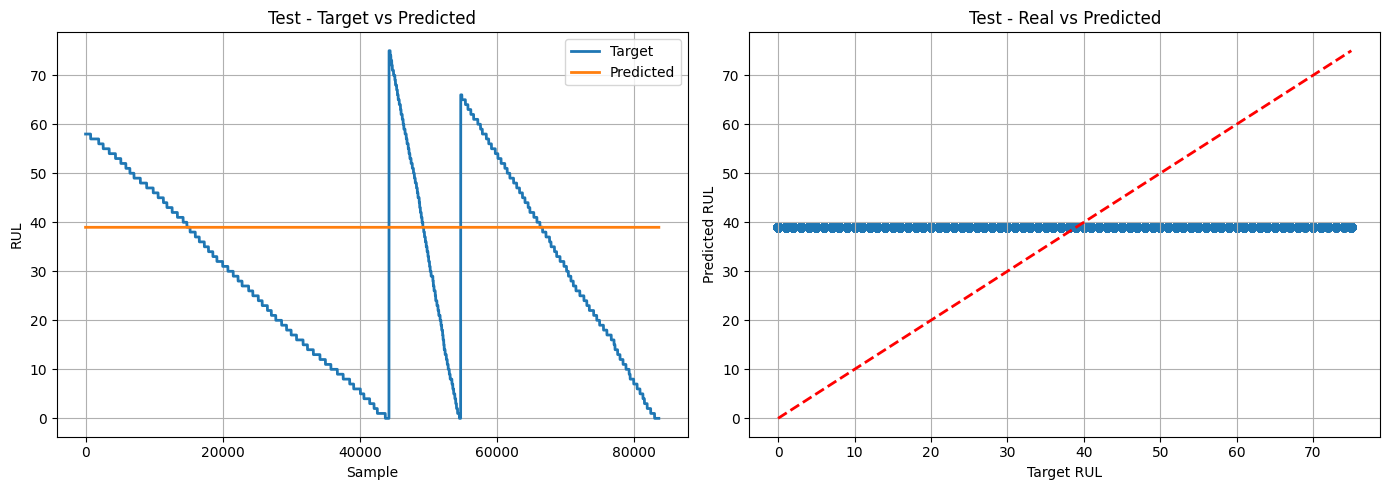

In [ ]:
train_engine_df = X_train_scaled_df[X_train_scaled_df['unit'] != 18]
val_engine_df   = X_train_scaled_df[X_train_scaled_df['unit'] == 18]

print(f"Shape of train_engine_df: {train_engine_df.shape} and engine units: {train_engine_df['unit'].unique()}")
print(f"Shape of val_engine_df: {val_engine_df.shape} and engine units: {val_engine_df['unit'].unique()}")
print(f"Shape of X_test_scaled_df: {X_test_scaled_df.shape} and engine units: {X_test_scaled_df['unit'].unique()}")

X_windows_train, Y_windows_train = create_windows(train_engine_df, features, window_size=50, stride=15)
X_windows_val, Y_windows_val     = create_windows(val_engine_df, features, window_size=50, stride=15)
X_windows_test, Y_windows_test = create_windows(X_test_scaled_df, features, window_size=50, stride=15)

print("X train normalized windows shape:",X_windows_train.shape,"\n Y train windows  shape:" , Y_windows_train.shape) 
print("X val windows shape:",X_windows_val.shape,"\n Y val windows  shape:" , Y_windows_val.shape) # engine (18) for validating
print("X test windows shape:",X_windows_test.shape,"\n Y test windows  shape:" , Y_windows_test.shape) 

dataset_train = CMAPSS(X_windows_train, Y_windows_train)
dataset_val   = CMAPSS(X_windows_val, Y_windows_val)
dataset_test  = CMAPSS(X_windows_test, Y_windows_test)

train_loader = DataLoader(dataset_train, batch_size=64, shuffle=True)
val_loader   = DataLoader(dataset_val, batch_size=64, shuffle=False)
test_loader  = DataLoader(dataset_test, batch_size=64, shuffle=False)

# all those params from optuna best params

model = FirstBaseline( 
    num_features=len(features),
    d_model=64,
    nhead=4,
    num_layers=2,
    dim_feedforward=128,
    dropout=0.10254532856431582
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0005207743283269423, # best lr trial 10
    weight_decay=1.031251860159177e-05
)

criterion = torch.nn.MSELoss()

model, train_preds, train_targets, val_preds, val_targets = train(
    criterion=criterion,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    model=model,
    num_epochs=10 
)

test_loss, test_rmse, test_nasa, test_preds, test_targets = test(model, test_loader, criterion)  # or val NASA score

plot_predictions(train_targets, train_preds, split_name="Train")
plot_predictions(val_targets, val_preds, split_name="Validation")
plot_predictions(test_targets, test_preds, split_name="Test")